## General Tutorial for Time Domain Simphony
This tutorial covers two compact examples designed for new Time-Domain Simphony users:
1. A time-domain Mach-Zehnder interferometer (MZI) driven by a Gaussian phase pulse that demonstrates how to use the simulator and define custom components that are not linear time-invariant.
2. A frequency-domain tour of a SiEPIC half-ring resonator that exhibits dispersion—showing how the simulator evaluates steady-state behaviour at different carrier wavelengths (equivalently, different optical center frequencies).

In [1]:
import os
os.environ["OPENBLAS_NUM_THREADS"] = "12"
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from simphony.circuit import Circuit
from simphony.circuit.components import SampleModeComponent
from simphony.libraries import siepic
from simphony.signals import SampleModeOpticalSignal
from simphony.simulation.sample_mode import SampleModeSimulation, SampleModeSimulationParameters
from simphony.simulation.s_parameter import SParameterSimulation
from pyparsing import Union
from ctypes import Array

To incorporate custom components you will need to import the `SampleModeComponent` base class. Any new component must:
- Inherit from `SampleModeComponent`.
- Declare the optical (and optional electrical/logic) ports it uses.
- Implement `sample_mode_initial_state(simulation_parameters)` to return the initial state that will be threaded through time.
- Implement `sample_mode_step(inputs, state, simulation_parameters)` to consume per-port signals and state at each time step and return a dictionary of output signals plus the next state.

`inputs` is a dictionary mapping each declared port name to a `SampleMode*Signal` object containing amplitudes and wavelengths at the current step. `state` is whatever object you returned from `sample_mode_initial_state`. The `simulation_parameters` dataclass bundles global settings such as the wavelength grid, time step `dt`, and total number of time steps. For performance-critical components, it is often helpful to keep the implementation JAX-jit compatible (pure functions, JAX arrays, and no side effects).

In [2]:
class StreamingCombSourceTime(SampleModeComponent):
    """Streaming multi-line optical comb source for sample-mode simulations."""
    # This component provides a set of continuous-wave tones defined by base_wavelengths.
    # The optical port names are arbitrary, but must match how the component is wired in the netlist.
    optical_ports = ["o0"]

    def __init__(self, base_wavelengths, scale=1.0):
        """Initialise the comb at the specified wavelengths.

        Parameters
        ----------
        base_wavelengths : array-like
            Optical carrier wavelengths (in meters) to emit on each line.
        scale : float, optional
            Field amplitude scaling applied to each tone, by default 1.0.
        """
        base = jnp.asarray(base_wavelengths, jnp.float32).reshape(-1)
        self.base = base
        self.num_lines = int(base.shape[0])
        self.scale = jnp.float32(scale)

    def sample_mode_initial_state(self, simulation_parameters):
        """Return initial per-line phases and a time-step index.

        The simulator threads this state through `sample_mode_step` at each time step.
        """
        phases = jnp.zeros((self.num_lines,), jnp.float32)
        t_idx = jnp.int32(0)
        return (phases, t_idx)

    def sample_mode_step(self, inputs, state, simulation_parameters):
        """Emit a constant-amplitude comb at every time step.

        Parameters
        ----------
        inputs : dict
            Dictionary of incoming signals on each declared port (unused here; the source
            is ideal and does not depend on upstream fields).
        state : tuple
            (phases, t_idx) tuple returned by `sample_mode_initial_state`.
        simulation_parameters : SampleModeSimulationParameters
            Global simulation configuration (time grid, wavelength grid, PRNG key, etc.).
        """
        phases, t_idx = state
        amplitude = (self.scale * jnp.exp(1j * phases).astype(jnp.complex64))[:, None]
        wavelengths = self.base.astype(jnp.float32)
        out = {"o0": SampleModeOpticalSignal(amplitude=amplitude, wavelength=wavelengths)}
        return out, (phases, t_idx + jnp.int32(1))

class OpticalPhaseModulator(SampleModeComponent):
    """Time-domain phase shifter that multiplies the forward field by e^{j·φ(t)}."""
    # Two-port device: o0 is the input, o1 is the output.
    optical_ports = ["o0", "o1"]

    def __init__(self, mod_signal, phase_bias=0.0):
        """Initialise a phase modulator driven by a sampled phase waveform.

        Parameters
        ----------
        mod_signal : array-like
            Real-valued phase samples (radians) defined on the simulation time grid.
        phase_bias : float, optional
            Static phase offset added to the drive, by default 0.0.
        """
        self.mod_signal = jnp.asarray(mod_signal, dtype=jnp.float32)
        self.phase_bias = jnp.float32(phase_bias)

    def sample_mode_initial_state(self, simulation_parameters):
        """Start with a time index of zero for the drive array."""
        return jnp.int32(0)

    def sample_mode_step(self, inputs, state, simulation_parameters):
        """Apply the current phase sample to the forward field at port o0.

        Parameters
        ----------
        inputs : dict
            Mapping from port name to `SampleModeOpticalSignal` arriving at that port.
        state : int
            Current time-step index into `mod_signal`.
        simulation_parameters : SampleModeSimulationParameters
            Global simulation configuration (not used directly here, but available for
            components that need access to the time grid or PRNG).
        """
        idx = jnp.minimum(state, self.mod_signal.shape[0] - 1)
        phase = self.mod_signal[idx] + self.phase_bias

        forward = inputs["o0"].amplitude
        wavelength = inputs["o0"].wavelength
        if forward.ndim == 1:
            forward = forward[:, None]

        transfer = jnp.exp(1j * phase).astype(forward.dtype)
        terminated = SampleModeOpticalSignal(jnp.zeros_like(forward), wavelength)
        modulated = SampleModeOpticalSignal(forward * transfer, wavelength)
        return {"o0": terminated, "o1": modulated}, state + jnp.int32(1)

def gaussian_phase(num_samples=600, peak_phase=jnp.pi, std_samples=70, dt=1e-12):
    """Return a time axis (seconds) and Gaussian phase waveform from 0 to `peak_phase`.

    The waveform is centred in the window with standard deviation `std_samples` in
    sample units, and can be used directly as the drive for `OpticalPhaseModulator`.
    """
    samples = np.arange(num_samples)
    center = 0.5 * (num_samples - 1)
    envelope = np.exp(-0.5 * ((samples - center) / std_samples) ** 2)
    phase = peak_phase * envelope
    time = samples * dt
    return time, phase

### Example 1 – Mach–Zehnder interferometer
We use the streaming comb laser from above as a continuous source, add a single custom optical phase modulator, and use the SiEPIC S-parameter models for the waveguides and Y-branches. The Gaussian phase pulse sweeps one arm of the interferometer from 0 to $\pi$, so the monitored output toggles between constructive and destructive interference.

This example shows that Time-Domain Simphony can mix SAX-compatible S-parameter models and hand-written sample-mode components in a single circuit. If you have S-parameters for a custom device, the framework can wrap them in a sample-mode component via a fitted state-space model, preserving dispersion, delays, attenuation, and mode coupling encoded in the S-parameter matrices.

**How to read the next cells**
- Cell 5 builds the MZI netlist, applies component settings, and draws the circuit topology.
- Cell 6 configures `SampleModeSimulationParameters`, runs the time-domain simulation, and extracts the monitored fields for plotting.

In [3]:
# Build the MZI and visualise its topology
num_samples = 10000
dt = 1e-14  # seconds per sample (1 ps)
carrier_wavelength = 1.55e-6  # 1550 nm telecom band

time_axis, phase_drive = gaussian_phase(num_samples=num_samples, std_samples=1000, dt=dt)
phase_drive_jax = jnp.asarray(phase_drive, dtype=jnp.float32)
optical_grid = jnp.array([carrier_wavelength], dtype=jnp.float32)
#Netlist defines the instances, connections, and ports of the circuit
# Each instance name on the left can be freely chosen, while the model names on the right must match those defined in the models dictionary below
# Connections define how the ports of each instance are connected to each other
# Ports define the ports of instances that will be tracked during simulation
netlist = {
    "instances": {
        "laser": "laser",
        "splitter": "y_branch",
        "upper_wg": "waveguide",
        "lower_wg": "waveguide",
        "phase": "phase_mod",
        "combiner": "y_branch",
    },
    "connections": {
        "laser,o0": "splitter,port_1",
        "splitter,port_2": "upper_wg,o0",
        "upper_wg,o1": "phase,o0",
        "phase,o1": "combiner,port_2",
        "splitter,port_3": "lower_wg,o0",
        "lower_wg,o1": "combiner,port_3",
    },
    "ports": {
        "output": "combiner,port_1",
    },
}
# Define the models that will be used in the circuit
models = {
    "laser": StreamingCombSourceTime,
    "y_branch": siepic.y_branch,
    "waveguide": siepic.waveguide,
    "phase_mod": OpticalPhaseModulator,
}
# Define the settings/parameters for each model. These will be passed to the model constructors during circuit creation
settings = {
    "laser": {
        "base_wavelengths": optical_grid,
        "scale": jnp.float32(1.0),
    },
    "splitter": {"pol": "te", "thickness": 220.0, "width": 500.0},
    "combiner": {"pol": "te", "thickness": 220.0, "width": 500.0},
    "upper_wg": {
        "pol": "te",
        "length": 200.0,
        "width": 500.0,
        "height": 220.0,
        "loss": 0.0,
    },
    "lower_wg": {
        "pol": "te",
        "length": 200.0,
        "width": 500.0,
        "height": 220.0,
        "loss": 0.0,
    },
    "phase": {
        "mod_signal": phase_drive_jax,
        "phase_bias": 0.0,
    },
}
# Create the circuit and display its topology. This is a networkx graph with all methods available from networkx.
circuit = Circuit(netlist=netlist, models=models)
circuit.display()

Initial state for laser computed
NUMBER OF POLES: 52


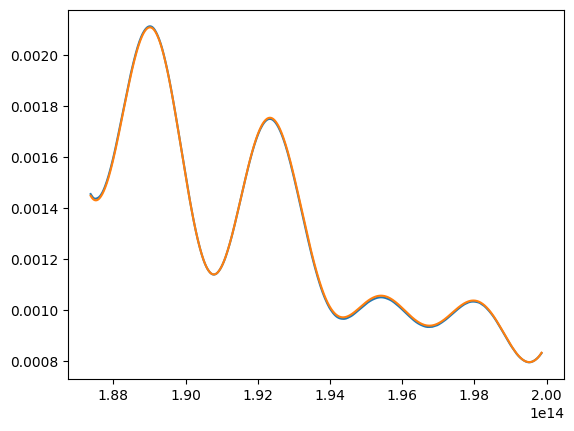

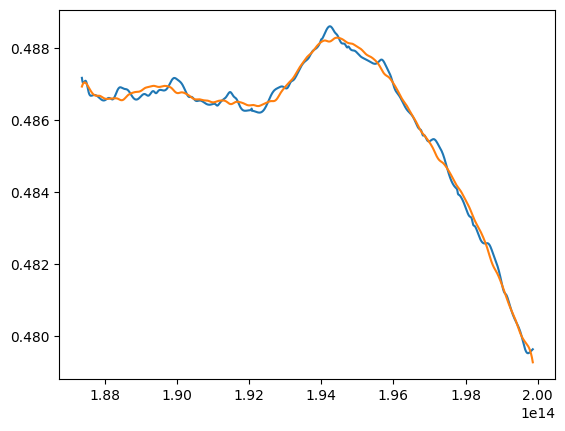

Initial state for splitter computed
NUMBER OF POLES: 52


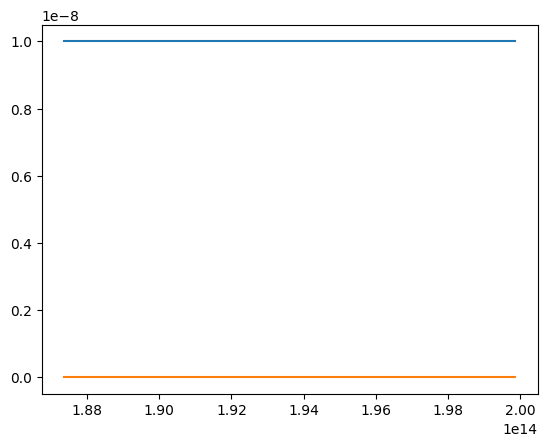

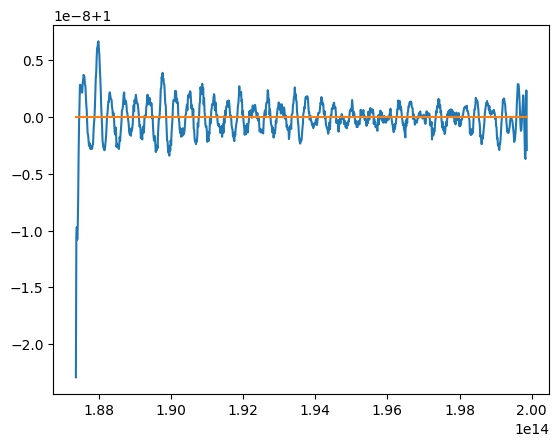

Initial state for upper_wg computed
NUMBER OF POLES: 52


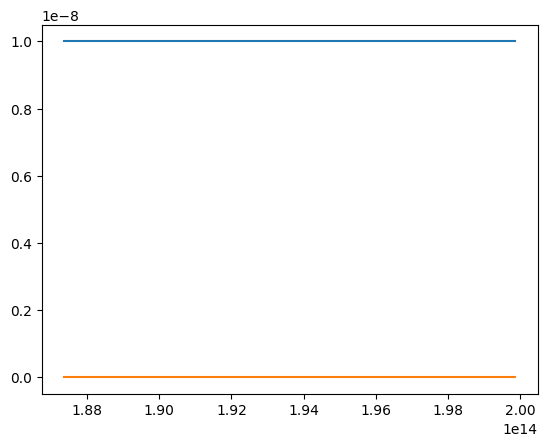

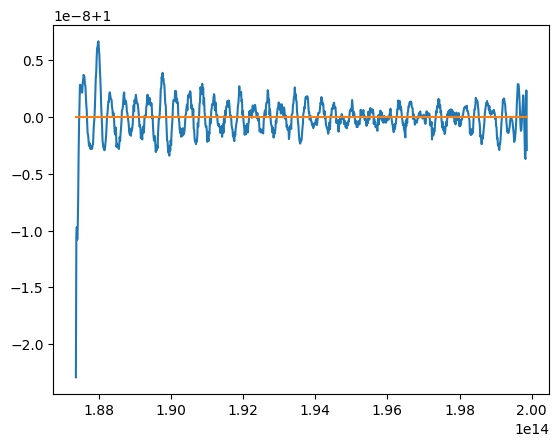

Initial state for lower_wg computed
Initial state for phase computed
NUMBER OF POLES: 52


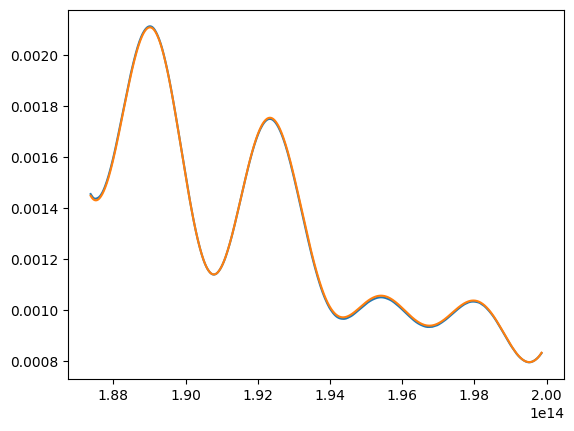

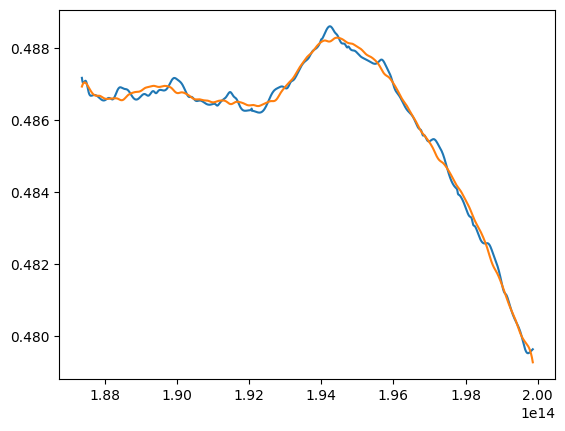

Initial state for combiner computed
Initial state for _optical_termination0 computed
Starting simulation...
Simulation time: 0.660 s


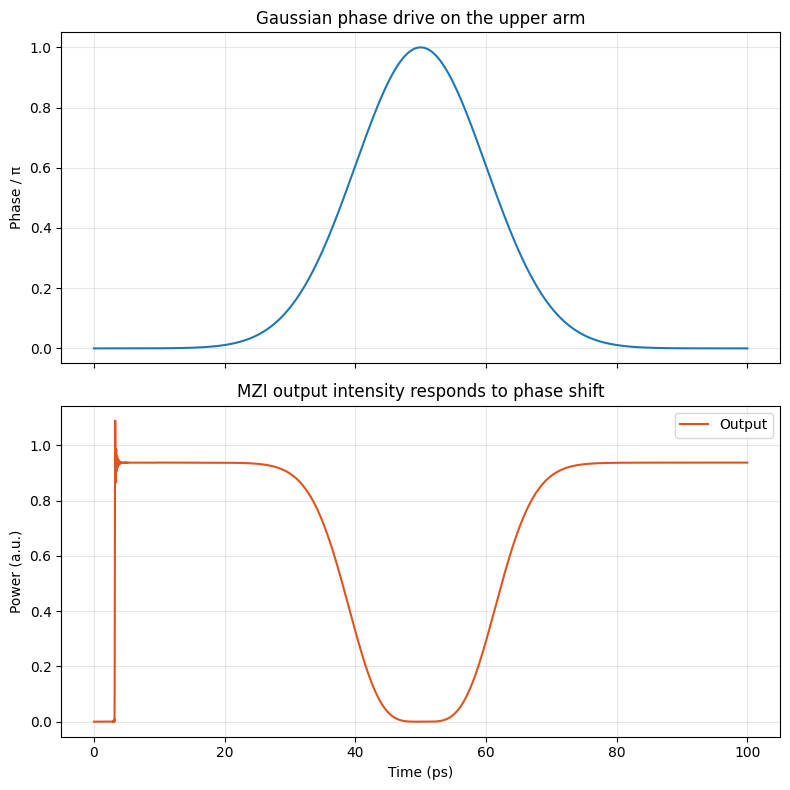

In [4]:
# Simulate the time-domain response of the MZI
sim = SampleModeSimulation(circuit)
# Define simulation parameters. These include the wavelengths to simulate, number of time steps, and time step size. 
#The simulation Parameters dataclass is passed to each component at each time step during simulation
parameters = SampleModeSimulationParameters(
    optical_baseband_wavelengths=optical_grid,
    num_time_steps=num_samples,
    sampling_period=dt,
)

# Run the simulation with the defined parameters and settings
tracked = sim.run(simulation_parameters=parameters, settings=settings)

# Outputs of the simulation are stored in a dictionary containing the tracked ports, their inputs and outputs, with both the amplitude and wavelength arrays
#The amplitude arrays are NxMx1 where N is the number of time steps and M is the number of wavelengths tracked 
# with the last dimension being 1 for future multi-mode support
output_field = np.asarray(tracked["output"]["output"].amplitude[:, 0, 0])
input_field = np.asarray(tracked["output"]["input"].amplitude[:, 0, 0])
#Returned outputs are complex field amplitudes, so to get power we take the absolute value squared
output_power = np.abs(output_field) ** 2
input_power = np.abs(input_field) ** 2

# Plot the Gaussian phase drive and resulting output intensity
fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)
axes[0].plot(time_axis * 1e12, phase_drive / np.pi)
axes[0].set_ylabel("Phase / π")
axes[0].set_title("Gaussian phase drive on the upper arm")
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis * 1e12, output_power, color="#de541e", label="Output")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Power (a.u.)")
axes[1].set_title("MZI output intensity responds to phase shift")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

### What to look for
- The SiEPIC `y_branch` models act as both splitter and combiner, so the constant source splits 50/50 before the arms re-interfere at the output. Each arm uses the same `siepic.waveguide` length so the only dynamic phase comes from our custom modulator.
- `SampleModeSimulation` logs both the forward and backward fields at every named port. In the code we grab `tracked["output"]["input"]` to see what is still flowing into the monitored junction and `tracked["output"]["output"]` for the outgoing wave.
- `SampleModeSimulationParameters` binds the discrete time grid (`num_time_steps` × `sampling_period`) to the optical comb we defined. Bumping `num_time_steps` or adding more wavelengths to `optical_baseband_wavelengths` lets you test longer drives or multi-line interference without changing the scaffolding.
- The Gaussian waveform we feed into the modulator gently rotates the optical phase from 0 to $\pi$, which drives the interference condition from constructive to destructive. The bottom plot shows the output intensity dip to nearly zero when the phase hits $\pi$.
- Because the simulator tracks both the incoming and outgoing fields at the monitored port, you can experiment further by adding static phase bias, extra waveguide length imbalance, or attenuation to emulate real photonic MZIs.

### Example 2 – Ring Resonator
SiEPIC ships measured half-ring resonators whose scattering data already encode dispersion. We sweep a continuous-wave laser across wavelength, evaluate the steady-state transmission, and show how the drop and through ports respond differently near resonance. This highlights the simulators ability to evaluate different carrier frequencies for the S-parameters half-rings.

First inspect the coupled topology with `SParameterSimulation`. The plot shows only the linear power transmission at the drop and through ports. We note resonances near 1.5485e-6 and off resonance at 1.56e-6

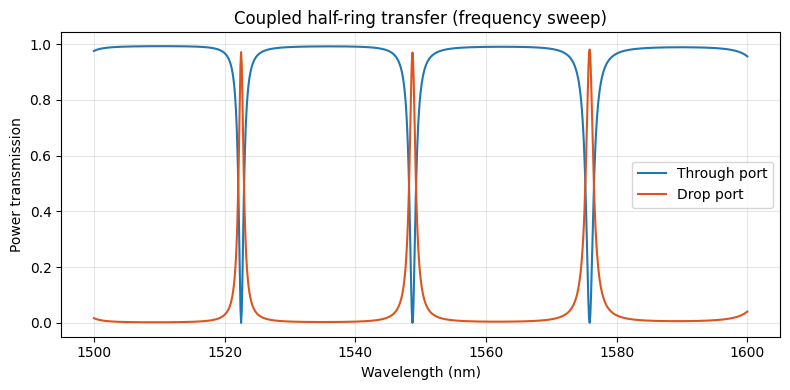

In [5]:
# Sweep the coupled half rings in the frequency domain
netlist_coupled_sparam = {
    "instances": {
        "ring_a": "half_ring",
        "ring_b": "half_ring",
        "dump": "terminator",
    },
    "connections": {
        "ring_a,port_1": "ring_b,port_1",
        "ring_a,port_3": "ring_b,port_3",
        "ring_b,port_4": "dump,port_1",
    },
    "ports": {
        "input": "ring_a,port_2",
        "through": "ring_a,port_4",
        "drop": "ring_b,port_2",
    },
}
settings_coupled_sparam = {
    # Mirror the exact defaults from siepic.half_ring so users see the baseline parameters.
    "ring_a": {
        "pol": "te",
        "gap": 50.0,          # nm
        "radius": 5.0,        # μm
        "width": 500.0,       # nm
        "thickness": 220.0,   # nm
        "coupling_length": 0.0,  # μm
    },
    "ring_b": {
        "pol": "te",
        "gap": 50.0,
        "radius": 5.0,
        "width": 500.0,
        "thickness": 220.0,
        "coupling_length": 0.0,
    },
    "dump": {"pol": "te"},
}
models_coupled_sparam = {
    "half_ring": siepic.half_ring,
    "terminator": siepic.terminator,
}
wavelengths = jnp.linspace(1.5e-6, 1.6e-6, 1000)
coupled_sparam_circuit = Circuit(netlist=netlist_coupled_sparam, models=models_coupled_sparam)
coupled_sparam = SParameterSimulation(coupled_sparam_circuit)
coupled_sparam_result = coupled_sparam.run(settings=settings_coupled_sparam, wl=wavelengths)

#For S-parameter components, the result contains a dictionary of S-parameters at the ports defined in the netlist
coupled_drop = np.asarray(coupled_sparam_result.s_parameters[("drop", "input")])
coupled_through = np.asarray(coupled_sparam_result.s_parameters[("through", "input")])
coupled_drop_power = np.abs(coupled_drop) ** 2
coupled_through_power = np.abs(coupled_through) ** 2
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(wavelengths * 1e9, coupled_through_power, label="Through port")
ax.plot(wavelengths * 1e9, coupled_drop_power, label="Drop port", color="#de541e")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Power transmission")
ax.set_title("Coupled half-ring transfer (frequency sweep)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### Coupled half rings (sample-mode drive)
With the resonant wavelength identified, drive the network with the streaming comb source at three tones: one locked to the resonance, one slightly detuned, and one farther away. We read the through port on the first ring (`port_4`) and the drop port on the second ring (`port_2`).

In [ ]:
# Build the coupled half-ring circuit with a three-line comb source
resonant_wavelength = 1.5486e-6  # on resonance
half_wavelength = 1.5491e-6  # near resonance
detuned_wavelength = 1.56e-6    # off resonance
ring_optical_lines = jnp.array([resonant_wavelength,half_wavelength, detuned_wavelength], dtype=jnp.float32)  # drive with resonant, slightly detuned, and off-resonant tones
ring_num_samples = 5000
ring_dt = 1e-14  # 10 fs
ring_time_axis = np.arange(ring_num_samples) * ring_dt

#We now incorporate non-S-parameter components into the coupled ring circuit for time-domain simulation
netlist_coupled = {
    "instances": {
        "laser": "laser",
        "ring_a": "half_ring",
        "ring_b": "half_ring",
    },
    "connections": {
        "laser,o0": "ring_a,port_2",
        "ring_a,port_1": "ring_b,port_1",
        "ring_a,port_3": "ring_b,port_3",
    },
    "ports": {
        "input": "ring_a,port_2",  # monitor the bus between rings
        "through": "ring_a,port_4",
        "drop": "ring_b,port_2",
    },
}

settings_coupled = {
    "laser": {
        "base_wavelengths": ring_optical_lines,
        "scale": jnp.float32(1.0),
    },
    # Reuse the built-in defaults from siepic.half_ring for both resonators.
    "ring_a": {
        "pol": "te",
        "gap": 50.0,
        "radius": 5.0,
        "width": 500.0,
        "thickness": 220.0,
        "coupling_length": 0.0,
    },
    "ring_b": {
        "pol": "te",
        "gap": 50.0,
        "radius": 5.0,
        "width": 500.0,
        "thickness": 220.0,
        "coupling_length": 0.0,
    },
}
coupled_models = {
    "laser": StreamingCombSourceTime,
    "half_ring": siepic.half_ring,
}
coupled_circuit = Circuit(netlist=netlist_coupled, models=coupled_models)
coupled_circuit.display()

: 

In [ ]:
# Run the sample-mode simulation for resonant vs. detuned wavelengths
coupled_sim = SampleModeSimulation(coupled_circuit)
coupled_params = SampleModeSimulationParameters(
    optical_baseband_wavelengths=ring_optical_lines,
    num_time_steps=ring_num_samples,
    sampling_period=ring_dt,
 )
tracked_coupled = coupled_sim.run(simulation_parameters=coupled_params, settings=settings_coupled)

# Convert tracked complex fields into power traces for each tone (single-mode assumption)
through_power_coupled = np.abs(tracked_coupled["through"]["output"].amplitude[:, :, 0]) ** 2
drop_power_coupled = np.abs(tracked_coupled["drop"]["output"].amplitude[:, :, 0]) ** 2
time_ps = ring_time_axis * 1e12
labels = [
    f"{resonant_wavelength * 1e9:.1f} nm (resonant)",
    f"{half_wavelength * 1e9:.1f} nm (near resonant)",
    f"{detuned_wavelength * 1e9:.1f} nm (detuned)",
]
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
for idx, ax in enumerate(axes):
    ax.plot(time_ps, through_power_coupled[:, idx], label="Ring A through")
    ax.plot(time_ps, drop_power_coupled[:, idx], label="Ring B drop", color="#de541e")
    ax.set_title(labels[idx])
    ax.set_xlabel("Time (ps)")
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel("Power (a.u.)")
axes[2].legend(loc="upper right")
plt.tight_layout()
plt.show()

Initial state for laser computed


**Coupled observations**
- The first panel (≈1548.6 nm) shows the resonant tone draining Ring A’s through port while Ring B’s drop port peaks, matching the steady-state sweep.
- The middle panel (≈1549.1 nm) demonstrates that a slight detune still shares power between rings—tweak `half_wavelength` to see how quickly the drop response fades.
- The third panel (1560 nm) confirms that a far-detuned tone stays in the bus; the drop trace stays flat while the through trace rides near its launch level.
- Because the streaming comb emits all wavelengths at once, a single `SampleModeSimulation` run yields all three traces—add more entries to `ring_optical_lines` to prototype WDM behaviour.
- Notice the transcience has slight bumbs as it slowly goes towards the steady-state these bumbs corresopnd to the light circulating around the ring and interfering during transcience

### Example 3 – Green Machine via pole–residue fitting
The Green Machine is an $8\times8$ optical interferometer that implements a unitary mixing matrix using cascaded directional couplers. Here we load its measured S-parameters, let Simphony auto-wrap them as a SAX-compatible component, and run a time-domain experiment that drives one input while monitoring every output port.

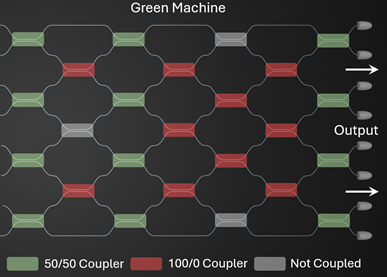

**What happens below**
- The measured scattering data from `gm_real_sdict_1p50_1p60um_1000pts.npz` is exposed as a SAX model by the `GM` callable from Cell 16.
- `Circuit` detects that `GM` is not a Python class, so it wraps it with `_optical_s_parameter`, fits a pole–residue (vector-fitting) state-space model, and produces a `SampleModeComponent` on the fly.
- We launch a single-line streaming comb through input `in7`, capture the steady-state output power, and compare it directly to the original S-parameter curves (similar plotting style to Cell 17).

In [ ]:
# Sample-mode drive of the Green Machine using pole–residue-fitted SAX S-parameters
def GM(wl: Union[float, Array] = 1.55):
    """Expose the measured Green Machine scattering data as a SAX model."""
    def load_sdict_npz(fname):
        data = np.load(fname)
        wavelengths = data["wavelengths"]
        sparams = {}
        for key in data.files:
            if key == "wavelengths":
                continue
            _, to_port, from_port = key.split("_", 2)
            sparams[(to_port, from_port)] = np.squeeze(data[key])
        return wavelengths, sparams
    _, Sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")
    return Sp

def load_sdict_npz(fname):
    data = np.load(fname)
    wavelengths = data["wavelengths"]
    sparams = {}
    for key in data.files:
        if key == "wavelengths":
            continue
        _, to_port, from_port = key.split("_", 2)
        sparams[(to_port, from_port)] = np.squeeze(data[key])
    return wavelengths, sparams

gm_wavelength_axis, gm_sp = load_sdict_npz("gm_real_sdict_1p50_1p60um_1000pts.npz")
gm_baseband = jnp.array([1.55e-6], dtype=jnp.float32)  # single comb line for clarity
gm_num_steps = 20000
gm_dt = 1e-14  # 10 fs sampling, matches earlier sections
gm_drive_port = "in7"

gm_netlist = {
    "instances": {
        "laser": "laser",
        "green_machine": "GM",
    },
    "connections": {
        "laser,o0": "green_machine,in7",
    },
    "ports": {f"o{i}": f"green_machine,out{i}" for i in range(8)},
}

gm_models = {
    "laser": StreamingCombSourceTime,
    "GM": GM,  # GM callable now available in this cell
}

gm_settings = {
    "laser": {
        "base_wavelengths": gm_baseband,
        "scale": jnp.float32(1.0),
    },
    "green_machine": {
        "max_order": 250,  # Upper bound on the pole–residue order used during fitting depending on the s-parameter complexity. 
    },
}

gm_circuit = Circuit(netlist=gm_netlist, models=gm_models)
gm_sim = SampleModeSimulation(gm_circuit)
gm_params = SampleModeSimulationParameters(
    optical_baseband_wavelengths=gm_baseband,
    num_time_steps=gm_num_steps,
    sampling_period=gm_dt,
 )

gm_tracked = gm_sim.run(simulation_parameters=gm_params, settings=gm_settings, tracked_ports=gm_netlist["ports"])
jax.block_until_ready(gm_tracked)  # ensure JAX finishes the simulation before plotting

gm_steady_step = gm_num_steps - 1
gm_steady_power = {}
for alias in gm_netlist["ports"].keys():
    steady_field = np.asarray(gm_tracked[alias]["output"].amplitude[gm_steady_step, 0, 0])
    gm_steady_power[alias] = float(np.abs(steady_field) ** 2)

gm_drive_wavelength = float(gm_baseband[0])
gm_steady_power

Initial state for laser computed
Initial state for green_machine computed
Initial state for _optical_termination0 computed
Initial state for _optical_termination1 computed
Initial state for _optical_termination2 computed
Initial state for _optical_termination3 computed
Initial state for _optical_termination4 computed
Initial state for _optical_termination5 computed
Initial state for _optical_termination6 computed
Initial state for _optical_termination7 computed
Initial state for _optical_termination8 computed
Initial state for _optical_termination9 computed
Initial state for _optical_termination10 computed
Initial state for _optical_termination11 computed
Initial state for _optical_termination12 computed
Initial state for _optical_termination13 computed
Initial state for _optical_termination14 computed
Starting simulation...
Initial state for green_machine computed
Initial state for _optical_termination0 computed
Initial state for _optical_termination1 computed
Initial state for _optic

{'o0': 0.018058663286605808,
 'o1': 0.021490473619464594,
 'o2': 0.01729708491469854,
 'o3': 0.0188241792701415,
 'o4': 0.020190407185852497,
 'o5': 0.0238984101432166,
 'o6': 0.02682848099160055,
 'o7': 0.019093843942899043}

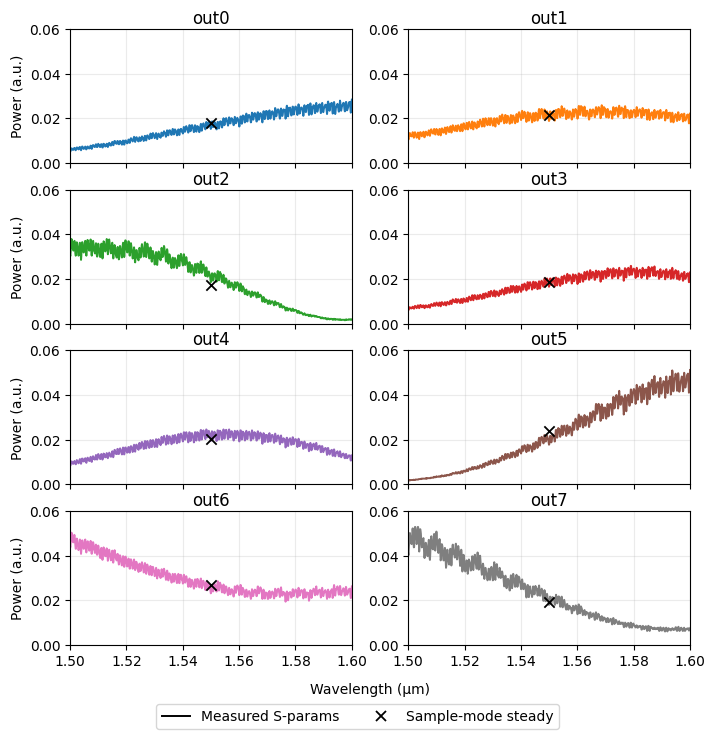

In [ ]:
# Compare measured S-parameters to the steady-state fields from the sample-mode run
from matplotlib.lines import Line2D

colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray"]
fig, axes = plt.subplots(4, 2, figsize=(8, 8), sharex=True)
axes = axes.flatten()

for idx, (alias, target) in enumerate(gm_netlist["ports"].items()):
    ax = axes[idx]
    color = colors[idx % len(colors)]
    gm_port = target.split(",")[1]
    s_key = (gm_port, gm_drive_port)
    s_curve = np.abs(gm_sp[s_key]) ** 2
    ax.plot(gm_wavelength_axis, s_curve, color=color, linewidth=1.4) 
    ax.scatter(
        gm_drive_wavelength * 1e6,gm_steady_power[alias],s=55,color="black",marker="x",linewidth=1.3,zorder=10,
    )
    ax.set_title(gm_port, pad=4)
    ax.grid(True, alpha=0.25)
    if idx % 2 == 0:
        ax.set_ylabel("Power (a.u.)")

for ax in axes:
    ax.set_xlim(1.50, 1.60)
    ax.set_ylim(0.0, 0.06)

legend_handles = [
    Line2D([0], [0], color="black", linewidth=1.4, label="Measured S-params"),
    Line2D(
        [0],[0],marker="x",color="black",markerfacecolor="white",linestyle="None",markersize=7,markeredgewidth=1.3, label="Sample-mode steady",
    ),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2)
fig.text(0.5, 0.05, "Wavelength (µm)", ha="center")
plt.show()